# Assignment 15: Loan Default Prediction
This notebook completes the data cleaning, feature engineering, model building, SHAP explainability, fairness analysis, and ethical discussion for the bank loan default assignment.

In [1]:

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_fscore_support

try:
    import shap
except ImportError:
    !pip install shap -q
    import shap


## Task 1: Load the Dataset

In [2]:

DATA_PATH = "bank-loan.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (850, 9)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


## Exploratory Data Analysis and Cleaning
The dataset has borrower information such as age, education, employment, income, debt-to-income ratio, credit debt, other debt, and default status. Rows with missing `default` are unlabeled, so they are kept aside and not used for supervised training.

In [3]:

print("Dataset information:")
print(df.info())
print("\nSummary statistics:")
display(df.describe())
print("\nMissing values:")
display(df.isna().sum())

labeled_df = df.dropna(subset=["default"]).copy()
print("Labeled rows used for model training:", labeled_df.shape[0])
print("Rows without default label kept aside:", df["default"].isna().sum())
print("Default rate in labeled data:", round(labeled_df["default"].mean(), 3))


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB
None

Summary statistics:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000



Missing values:


,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


Labeled rows used for model training: 700
Rows without default label kept aside: 150
Default rate in labeled data: 0.261


### Visualizations and Observations
The target distribution shows more non-default borrowers than default borrowers, meaning the dataset is imbalanced. Debt-to-income ratio is expected to be important because borrowers with heavier debt pressure are more likely to default.

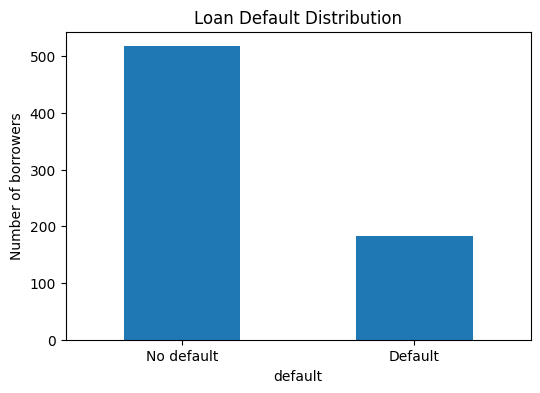

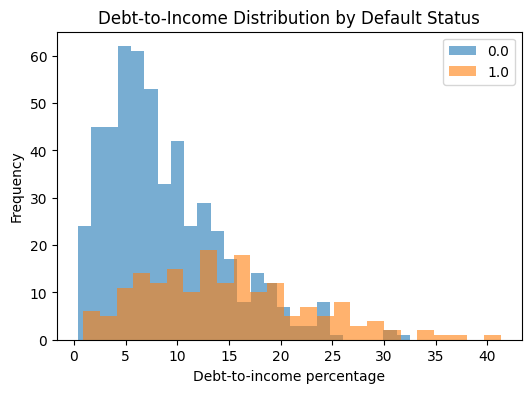

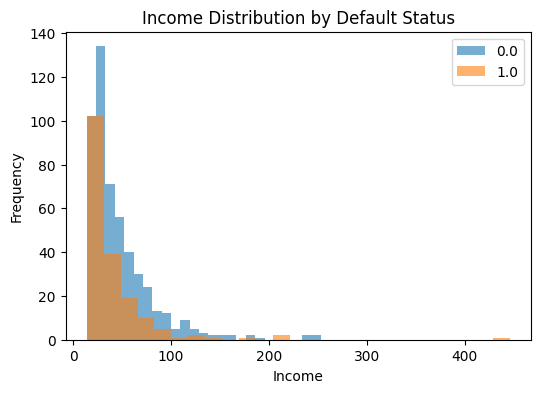

In [4]:

plt.figure(figsize=(6,4))
labeled_df["default"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["No default", "Default"], rotation=0)
plt.title("Loan Default Distribution")
plt.ylabel("Number of borrowers")
plt.show()

plt.figure(figsize=(6,4))
labeled_df.groupby("default")["debtinc"].plot(kind="hist", bins=25, alpha=0.6, legend=True)
plt.title("Debt-to-Income Distribution by Default Status")
plt.xlabel("Debt-to-income percentage")
plt.show()

plt.figure(figsize=(6,4))
labeled_df.groupby("default")["income"].plot(kind="hist", bins=25, alpha=0.6, legend=True)
plt.title("Income Distribution by Default Status")
plt.xlabel("Income")
plt.show()


## Task 2: Feature Engineering and Scaling
New features are created to capture total debt, the share of credit debt, estimated debt amount, employment stability, and employment relative to age. Scaling is included in the pipeline to keep numerical features consistent.

In [5]:

# Data cleaning and feature engineering
work = df.copy()

# Create useful features from existing columns
work["total_debt"] = work["creddebt"] + work["othdebt"]
work["credit_debt_ratio"] = work["creddebt"] / (work["total_debt"] + 1e-6)
work["debt_to_income_amount"] = work["income"] * work["debtinc"] / 100
work["employment_to_age_ratio"] = work["employ"] / (work["age"] + 1e-6)
work["stability_score"] = work["employ"] + work["address"]

# Groups used later for fairness checking. The dataset does not contain gender.
work["age_group"] = pd.cut(work["age"], bins=[0,30,45,100], labels=["Under 30", "30-45", "Over 45"])
work["education_group"] = work["ed"].map({1:"Basic",2:"High school",3:"College",4:"University",5:"Graduate"}).fillna("Other")

model_df = work.dropna(subset=["default"]).copy()
X = model_df.drop(columns=["default", "age_group", "education_group"])
y = model_df["default"].astype(int)

feature_names = X.columns.tolist()
print("Features used:", feature_names)


Features used: ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt', 'total_debt', 'credit_debt_ratio', 'debt_to_income_amount', 'employment_to_age_ratio', 'stability_score']


## Task 3: Model Building and Evaluation
A Random Forest classifier is used because it handles non-linear relationships and provides feature importance. Class weights are balanced because default cases are fewer than non-default cases.

Accuracy: 0.777

Classification Report:
              precision    recall  f1-score   support

  No default       0.91      0.78      0.84       129
     Default       0.55      0.78      0.65        46

    accuracy                           0.78       175
   macro avg       0.73      0.78      0.74       175
weighted avg       0.82      0.78      0.79       175



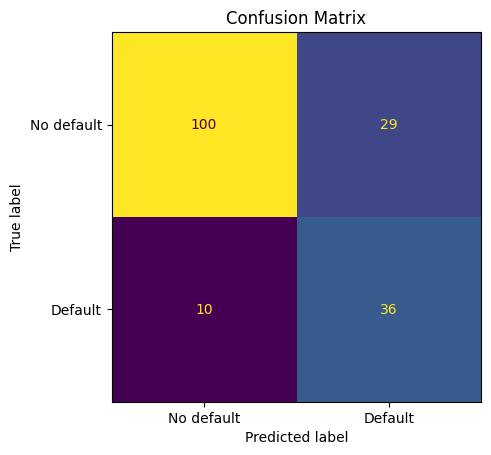

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=6,
        min_samples_leaf=5
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No default", "Default"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(values_format="d", colorbar=False)
plt.title("Confusion Matrix")
plt.show()


### Feature Importance
Feature importance helps identify which borrower characteristics have the strongest relationship with predicted default risk.

employment_to_age_ratio    0.149542
debtinc                    0.139727
employ                     0.114173
stability_score            0.100945
creddebt                   0.097589
total_debt                 0.066350
debt_to_income_amount      0.066010
credit_debt_ratio          0.058835
othdebt                    0.051372
age                        0.048219
dtype: float64


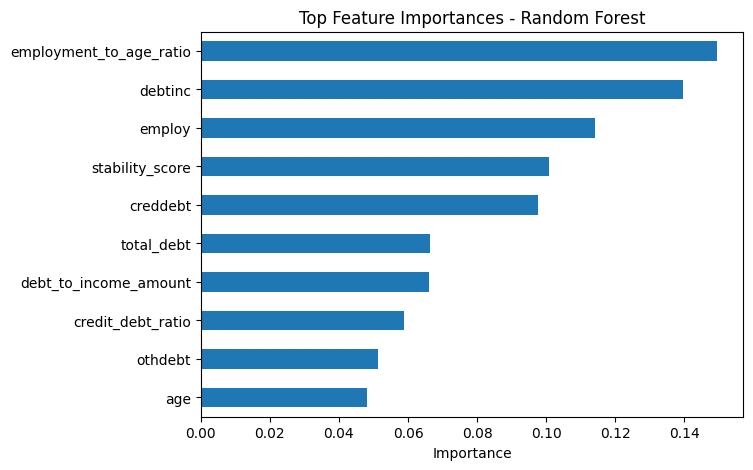

In [7]:

rf = model.named_steps["classifier"]
feature_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print(feature_importance.head(10))

plt.figure(figsize=(7,5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()


## Task 4: Explainability and Fairness Analysis
SHAP explains model predictions by showing which features contribute most to the default class. Fairness is assessed using age and education groups because the dataset does not contain gender.

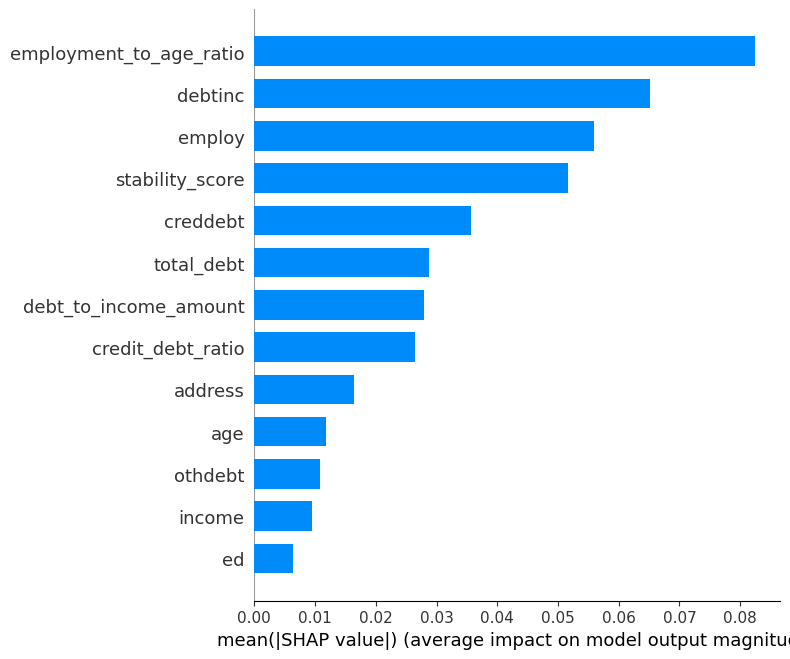

In [8]:

# SHAP explainability
X_sample = X_test.sample(min(100, len(X_test)), random_state=42)
X_scaled_sample = model.named_steps["scaler"].transform(X_sample)
explainer = shap.TreeExplainer(model.named_steps["classifier"])
shap_values = explainer.shap_values(X_scaled_sample)

# For binary classification, use the SHAP values for the default class.
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_values_default = shap_values[:, :, 1]
else:
    shap_values_default = shap_values

shap.summary_plot(shap_values_default, X_sample, feature_names=feature_names, plot_type="bar")


In [9]:

# Fairness analysis using age and education groups because this dataset has no gender variable.
fairness = model_df.loc[X_test.index, ["age_group", "education_group"]].copy()
fairness["actual"] = y_test.values
fairness["predicted"] = y_pred

def group_metrics(data, group_col):
    rows = []
    for group, part in data.groupby(group_col, observed=False):
        if len(part) < 5:
            continue
        precision, recall, f1, _ = precision_recall_fscore_support(
            part["actual"], part["predicted"], average="binary", zero_division=0
        )
        rows.append({
            "group": str(group),
            "n": len(part),
            "accuracy": accuracy_score(part["actual"], part["predicted"]),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "predicted_default_rate": part["predicted"].mean(),
            "actual_default_rate": part["actual"].mean()
        })
    return pd.DataFrame(rows)

age_fairness = group_metrics(fairness, "age_group")
education_fairness = group_metrics(fairness, "education_group")

print("Fairness by age group:")
display(age_fairness.round(3))
print("Fairness by education group:")
display(education_fairness.round(3))


Fairness by age group:


,group,n,accuracy,precision,recall,f1_score,predicted_default_rate,actual_default_rate
0,Under 30,54,0.741,0.640,0.762,0.696,0.463,0.389
1,30-45,103,0.777,0.438,0.737,0.549,0.311,0.184
2,Over 45,18,0.889,0.750,1.000,0.857,0.444,0.333


Fairness by education group:


,group,n,accuracy,precision,recall,f1_score,predicted_default_rate,actual_default_rate
0,Basic,89,0.820,0.600,0.714,0.652,0.281,0.236
1,College,25,0.800,0.714,0.909,0.800,0.560,0.440
2,High school,47,0.702,0.333,0.750,0.462,0.383,0.170
3,University,11,0.636,0.571,0.800,0.667,0.636,0.455


## Task 5: Ethical Considerations and Recommendations

In [10]:

print("""
Ethical considerations:
1. Fairness: The model was checked across age and education groups. Accuracy and default prediction rates were compared to identify possible differences in treatment.
2. Privacy: Only variables available in the public dataset were used. No names or direct personal identifiers were included.
3. Transparency: Feature importance and SHAP were used to explain which variables influenced default predictions.
4. Bias improvement: The institution should monitor performance across demographic groups, review borderline cases manually, and avoid using the model as the only decision-maker.

Recommendations:
- Pay close attention to borrowers with high debt-to-income ratio and high credit debt.
- Use the model as a risk-screening tool, not as an automatic rejection system.
- Offer financial counselling, repayment restructuring, and early reminders to higher-risk borrowers.
- Re-train and audit the model regularly with newer data.
""")



Ethical considerations:
1. Fairness: The model was checked across age and education groups. Accuracy and default prediction rates were compared to identify possible differences in treatment.
2. Privacy: Only variables available in the public dataset were used. No names or direct personal identifiers were included.
3. Transparency: Feature importance and SHAP were used to explain which variables influenced default predictions.
4. Bias improvement: The institution should monitor performance across demographic groups, review borderline cases manually, and avoid using the model as the only decision-maker.

Recommendations:
- Pay close attention to borrowers with high debt-to-income ratio and high credit debt.
- Use the model as a risk-screening tool, not as an automatic rejection system.
- Offer financial counselling, repayment restructuring, and early reminders to higher-risk borrowers.
- Re-train and audit the model regularly with newer data.

